## Step 0 - Setup and Sector Filter

In [1]:
# To start, I import the different libreries: the first, panda, to organize the data, the second, numpy, to do numerical operations and the third to visualize graphically our data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
# Then I upload the dataset (and I indicate the path that jupyter have to do), but in raw terms and then I organize just to visualize the firsts observations. 

df_raw = pd.read_csv("data/symbol_info_3-25.csv")

print("dataset firts observation", df_raw.shape)

df_raw.head()

dataset firts observation (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,...,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,...,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,...,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,...,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,...,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [3]:

# To start I copy the dataset because it's always the best way to work so that the dataset isn't corrupted.

df = df_raw.copy()

df = df [
    (df["is_etf"]== 0) &
    (df["is_fund"]== 0) &
    (df["is_actively_trading"] == 1) & 
    (df["market_cap"] > 0) &   
    (df["total_revenue"] > 0) &
    (df["sector"] == "Real Estate")
].copy()

# I set ETFs and the funds == 0, the active trading == 1, the market capitalization and the total revenue > 0 (it would 
# not make sense if it we'll be with value equal to 0), and then, the last condition was the sector that in my case is 
# equal to "Real Estate" (9). 
    


# I convert the dollar into billions so it's more readeble. I first try whithout this conversion and it was really 
# really confused. For this reason I see that with the conversion it's more clear in the table.

df["market_cap_bil"] = df["market_cap"] / 1e9
df["enterprise_value_bil"] = df["enterprise_value"] / 1e9
df["revenue_bil"] = df["total_revenue"] / 1e9
df["net_income_bil"] = df["net_income"] / 1e9
df["free_cashflow_bil"] = df["free_cashflow"] / 1e9

# I do the converison also for the percentage number so from 0.436 it became 43.61 that is more intuitive. 

df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100


# As the last task to make the table more readable I replace the infinite value into a Not a Number. 
# Because I saw that, in general, the number that are infinite can make spread value that can be probably not coherent 
# with the study and, especially, not readable for panda and matlib. So for this reason I also do this replacements.

df = df.replace([np.inf, -np.inf], np.nan)


# To visualize the finale table with some of mine observations I taka the head:
 
print("Cleaned dataset:", df.shape)
df[["symbol", "company_name", "sector", "market_cap_bil", "revenue_bil", "profit_margin_pct", "beta"]].head()

Cleaned dataset: (55, 48)


,symbol,company_name,sector,market_cap_bil,revenue_bil,profit_margin_pct,beta
110,PLD,"Prologis, Inc.",Real Estate,103.873184,8.555233,43.618000,1.112
112,AMT,American Tower Corporation (REI,Real Estate,101.078221,10.127200,22.267000,0.861
122,WELL,Welltower Inc.,Real Estate,94.842986,7.991118,11.909001,1.191
136,EQIX,"Equinix, Inc.",Real Estate,82.899657,8.737000,9.328000,0.734
193,SPG,"Simon Property Group, Inc.",Real Estate,62.003900,5.963798,39.755002,1.802


## Step 1 - Market Capitalizaton Distribution

In [4]:
# After a firts try I add the mena and median.
# In the firts try I saw that without the billion and percentage formatter the billions were like "20,000,000,000" and it
# confused. So I use the formatter that I saw from the first document. 


# for the billions, then the number will be in decimal term
 
def billions_formatter (x, pos):
    return f"{x:,.0f}B"

#for the percentage, so the percentace can be easily readeble especially for the mean and median

def percentage_formatter (x, pos):
    return f"{x:.0f}%" 


# then I use the function to set the graph, in such a way that they are alligned
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax
    

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=12)

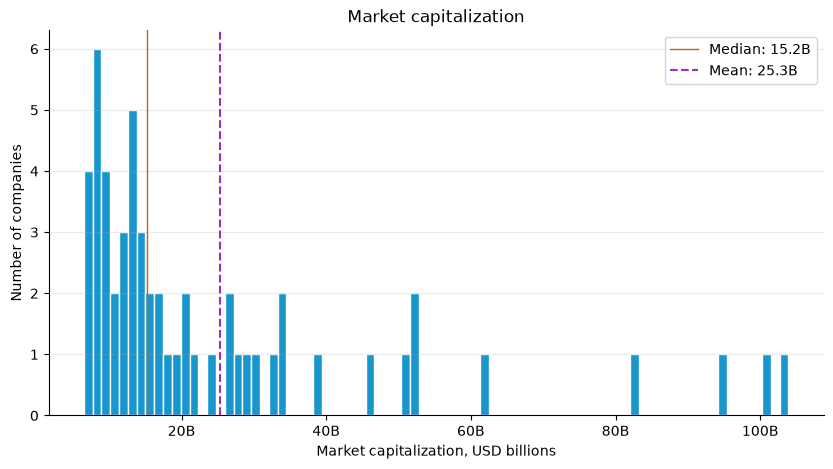

In [14]:
# I set the graph on the argument that I have to represent (the market capitalization of Real Estate) and I calculate the
# mean and median.

market_cap = df ["market_cap_bil"].dropna()
market_cap_mean = market_cap.mean()
market_cap_median = market_cap.median()


# (it's a subplot because there are many intruments that have to be represented)
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    market_cap,
    bins= 80,
    color = "#1797ce",
    edgecolor= "white",
    alpha= 1
) 


# I set the structure of how mean and meadian should appear. "axvline" design a vertical line in the graph, then I set the
# color, the linestyle and line width of the market_cap_median and mean.
ax.axvline(market_cap_median, color="#ca6210", linestyle="solid", linewidth=1, label=f"Median: {market_cap_median:,.1f}B")
ax.axvline(market_cap_mean, color="#a02dc1", linestyle="--", linewidth=1.5, label=f"Mean: {market_cap_mean:,.1f}B")


# I set the title nd the lable and, for the x axis I use the billions formatter.
ax.set_title("Market capitalization")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")

ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

ax.grid(axis="y", alpha=0.25)
ax.legend()  
clean_spines(ax)

plt.show()

## Step 2 - Outlier Detection

I first have to remove outliers because (as we can see from the preview graph) there are a lot of them.

/tmp/ipykernel_6011/3633978910.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


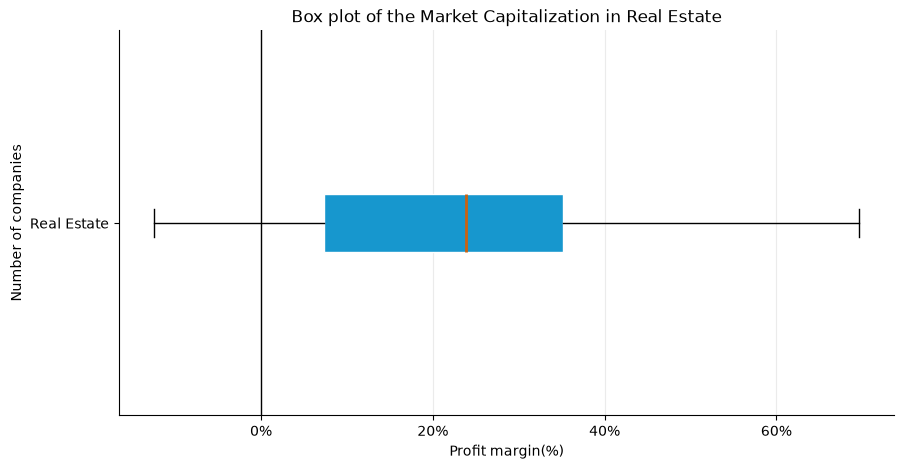

In [15]:
# I keep only the Real Estate sector and remove the outliers to keep just that value that have profit margin capitalization 
# positive numbersvalues.

box_df = df [

    (df["market_cap_bil"] >= 1) &
    (df["profit_margin_pct"].between(-50,80)) &
    (df["sector"] == "Real Estate")
].dropna(subset=("sector", "market_cap_bil")).copy()


# Then I order by industry in an ascending wy 
sector_or = (

    box_df.groupby("sector")["profit_margin_pct"]
    .median()
    .sort_values(ascending = True)
    .index
)

# I set the input of the boxplot
box_data = [
    box_df.loc[box_df["sector"] == sector, "profit_margin_pct"].values
    for sector in sector_or
]


fig, ax = plt.subplots(figsize = (10, 5))

ax.boxplot(

    box_data,                  # that are our input order by sector Real Estate
    tick_labels = sector_or,   
    vert = False,              # since the box plot hav to be horizonta
    
    # to be able to set color I add 

    patch_artist= True, 
    boxprops= {"facecolor": "#1797ce", "edgecolor" : "white"},   # color of box
    medianprops= {"color" : "#ca6210", "linewidth" : 2 },        # color of median
    whiskerprops= {"color" : "#000000"},                         # color of whisker
    capprops= {"color" : "#000000"},
    flierprops= {"marker": "o", "markersize": 3, "alpha": 0.35}
)

ax.axvline(0, color= "black", linewidth = 1)

#Then I set the title and the label of the axes

ax.set_title("Box plot of the Market Capitalization in Real Estate")
ax.set_xlabel("Profit margin(%)")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(percentage_formatter))
ax.grid(axis="x", alpha= 0.25)
clean_spines(ax)


plt.show()

## Step 3 - Industry Comparison: Four Metrics

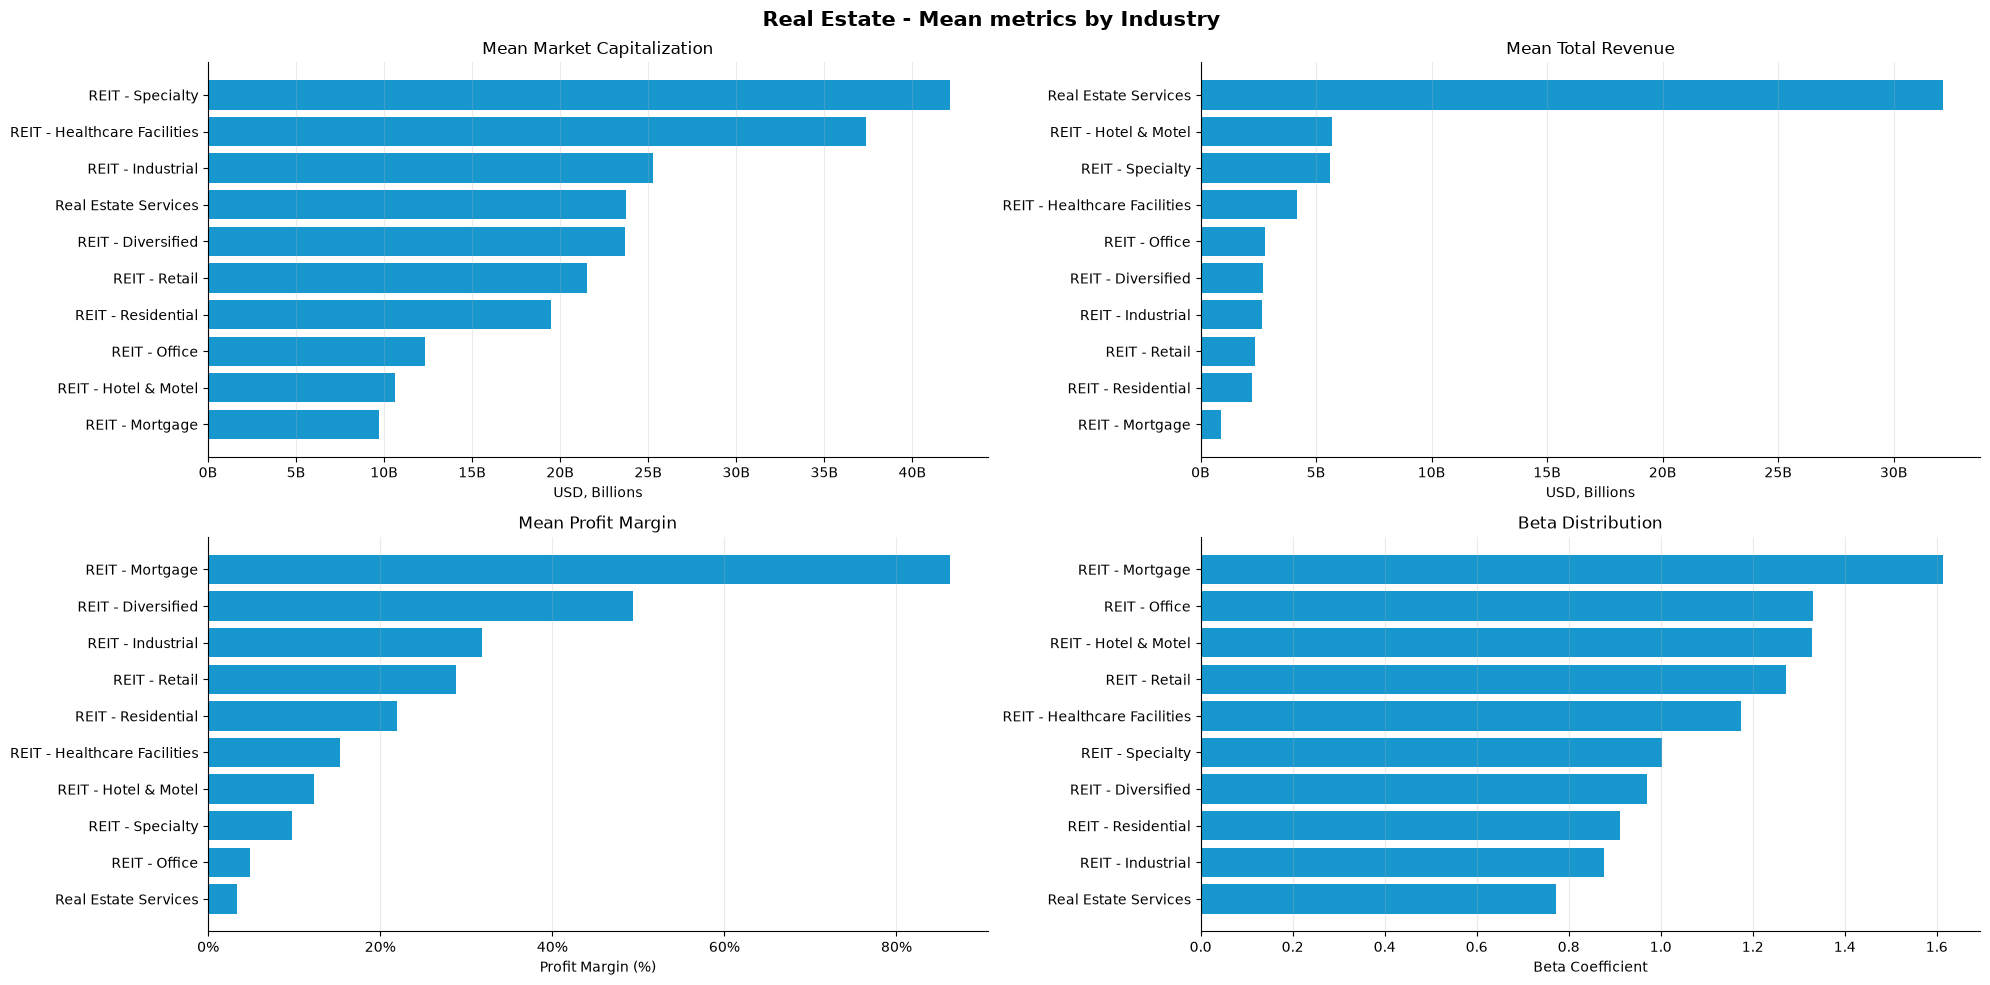

In [16]:
# First I have to prepare the dataframe for the 4 subplots, and since it is by the mean I do the mean of the data. 
# I grouped the oservation by the industry in  which the metrics are represented by the x axis.

industry_mean = df.groupby("industry")[["market_cap_bil", "revenue_bil","profit_margin_pct", "beta"]].mean()

# The I set the general condition of the entire graph. It will have 2 columns and two rows according to the var

fig, axes = plt.subplots(
    nrows= 2,
    ncols=2,
    figsize=(20,10),
)
 
# The first subplots: MARKET CAPITALIZATION (BIL).  

top_cap= industry_mean ["market_cap_bil"].dropna().sort_values()

# I set the general instructions of the graph, barh color, title etc

axes [0, 0].barh(top_cap.index, top_cap.values, color= "#1797ce")

axes [0, 0].set_title("Mean Market Capitalization")
axes [0, 0].set_xlabel("USD, Billions")

axes [0, 0].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes [0, 0].grid(axis="x", alpha=0.25)
clean_spines(axes [0, 0])


# The second subplots: TOTAL REVENUE (BIL)

top_rev= industry_mean["revenue_bil"].dropna().sort_values()

axes [0, 1].barh(top_rev.index, top_rev.values, color= "#1797ce")

axes [0, 1].set_title("Mean Total Revenue")
axes [0, 1].set_xlabel("USD, Billions")

axes [0, 1].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes [0, 1].grid(axis="x", alpha=0.25)
clean_spines(axes [0, 1])


# The third subplots: PROFIT MARGINS (%)

top_margin= industry_mean["profit_margin_pct"].dropna().sort_values()
axes [1, 0].barh(top_margin.index, top_margin.values, color= "#1797ce")

axes [1, 0].set_title("Mean Profit Margin")
axes [1, 0].set_xlabel("Profit Margin (%)")

# In this case I will use the percentage fromatter

axes [1, 0].xaxis.set_major_formatter(FuncFormatter(percentage_formatter))
axes [1, 0].grid(axis="x", alpha=0.25)
clean_spines(axes[1, 0])

# The fourth subplots: BETA 

top_beta= industry_mean["beta"].dropna().sort_values()
axes [1, 1].barh(top_beta.index, top_beta.values, color= "#1797ce")

axes [1, 1].set_title("Beta Distribution")
axes [1, 1].set_xlabel("Beta Coefficient")

axes [1, 1].grid(axis="x", alpha=0.25)
clean_spines(axes [1, 1])

# As final step I set the title and fontsize of the final graph 
plt.suptitle("Real Estate - Mean metrics by Industry ", fontsize= 15, fontweight= "bold")
plt.tight_layout()


plt.show()

## Step 4 - Industry Dispersion

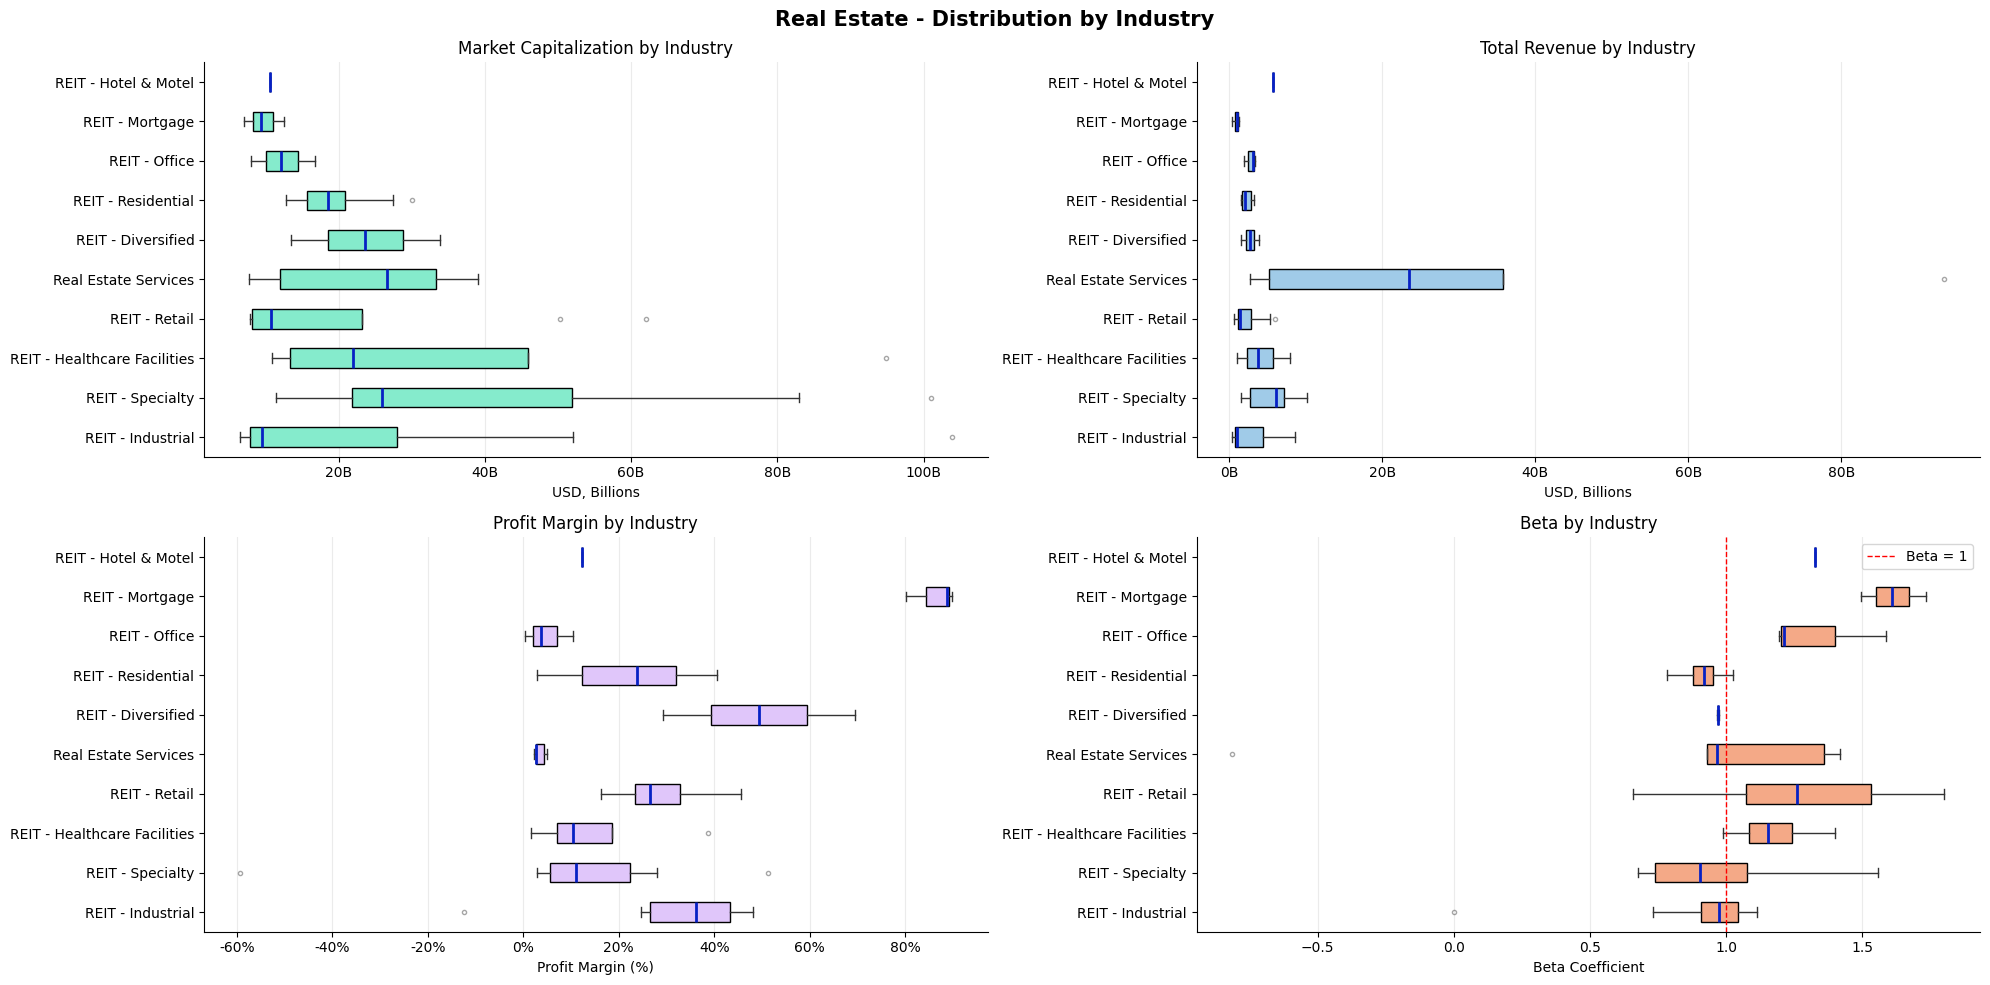

In [23]:
# To do the boxplots for the industries I first define it as the "industry" from the dataframe

industries = df["industry"].dropna().unique()

# I set the general instructions of the graph

fig, axes = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(20, 10))



# FIRST SUBPLOT: MARKET CAPITALIZATION

# I do a list for each industry in which each industry is filtered just to keep the companies of REIT(Real Estate). 
# Then extract the market capitalization in billions terms. 

box_data = [df[df["industry"] == ind]["market_cap_bil"].dropna().values for ind in industries]

# To plot the boxplots I set the intructions as the previews subplots, that is organized as a matrix in horizontal way

axes[0, 0].boxplot(box_data, tick_labels=industries, vert=False, patch_artist=True,

    boxprops={"facecolor": "#85ebcc"}, medianprops={"color": "#0721c4", "linewidth": 2},     # to set the color and the median properties
    whiskerprops={"color": "#333333"}, capprops={"color": "#333333"},                        # to set the wisker 
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35})                              # style of outlier

# Then I set the general things like title and labels

axes[0, 0].set_title("Market Capitalization by Industry")
axes[0, 0].set_xlabel("USD, Billions")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes[0, 0].grid(axis="x", alpha=0.25)
clean_spines(axes[0, 0])

# SECOND SUBPLOT: TOTAL REVENUE
box_data = [df[df["industry"] == ind]["revenue_bil"].dropna().values for ind in industries]

axes[0, 1].boxplot(box_data, tick_labels=industries, vert=False, patch_artist=True,

    boxprops={"facecolor": "#A0CBE8"}, medianprops={"color": "#0721c4", "linewidth": 2},
    whiskerprops={"color": "#333333"}, capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35})

axes[0, 1].set_title("Total Revenue by Industry")
axes[0, 1].set_xlabel("USD, Billions")
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes[0, 1].grid(axis="x", alpha=0.25)
clean_spines(axes[0, 1])

# THIRD SUBPLOT: PROFIT MARGIN
box_data = [df[df["industry"] == ind]["profit_margin_pct"].dropna().values for ind in industries]

axes[1, 0].boxplot(box_data, tick_labels=industries, vert=False, patch_artist=True,
    boxprops={"facecolor": "#e0c6fa"}, medianprops={"color": "#0721c4", "linewidth": 2},
    whiskerprops={"color": "#333333"}, capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35})

axes[1, 0].set_title("Profit Margin by Industry")
axes[1, 0].set_xlabel("Profit Margin (%)")
axes[1, 0].xaxis.set_major_formatter(FuncFormatter(percentage_formatter))
axes[1, 0].grid(axis="x", alpha=0.25)
clean_spines(axes[1, 0])

# FOURTH SUBPLOT: BETA
box_data = [df[df["industry"] == ind]["beta"].dropna().values for ind in industries]

axes[1, 1].boxplot(box_data, tick_labels=industries, vert=False, patch_artist=True,
    boxprops={"facecolor": "#f4a987"}, medianprops={"color": "#0721c4", "linewidth": 2},
    whiskerprops={"color": "#333333"}, capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35})

axes[1, 1].set_title("Beta by Industry")
axes[1, 1].set_xlabel("Beta Coefficient")
axes[1, 1].axvline(1, color="red", linestyle="--", linewidth=1, label="Beta = 1")
axes[1, 1].grid(axis="x", alpha=0.25)
axes[1, 1].legend()
clean_spines(axes[1, 1])


# Then I set the general title 

plt.suptitle("Real Estate - Distribution by Industry", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 5 - Focus Industry Selection

In [24]:
# So based on the graphs of spet 3 and 4 I select 4 industries, where each of them reflect a specific condition observable from the graphs.

sel_industries = [

    "REIT - Specialty",  

    "Real Estate Services",

    "REIT - Diversified",

    "REIT - Mortgage"

]

df = df[df["industry"].isin(sel_industries)].copy()

print("Companies selected:", df.shape[0])

print()

Companies selected: 19



The "REIT – Specialty" sector has the widest distribution in terms of market capitalisation, with a median of around $22 billion, but with values reaching as high as $100 billion, indicating considerable variability among companies in this sector. Revenues remain relatively low and concentrated, whilst the profit margin has a median of around 10% with a moderately high distribution. The beta stands at around 1 but with a significant spread.

The "Real Estate Services" sector has the highest total revenue of all sectors, ranging up to $40 billion with an outlier figure of nearly $80 billion. However, this high revenue does not translate into profitability: the profit margin is the lowest of the four selected sectors, standing at just over 0%. Market capitalisation is moderate and the beta is above 1.

While "REIT - Diversified" sector appears to be the most balanced across all four parameters considered. It has a moderate market capitalization, ranging between $20 billion and $25 billion, modest but stable revenue, and one of the highest profit margins, with a median of around 40–50%. Its beta is also below 1.0, making it the most stable and least risky of the four selected sectors.

And at the last, the "REIT – Mortgages" sector has the most extreme profile. It has the lowest market capitalisation and the lowest total revenue of all the selected sectors, with distributions heavily concentrated around zero. However, it compensates with the highest profit margin of all — with a median approaching 80% and the highest beta, significantly above 1.5. This combination is consistent with financial theory: higher returns always entail greater risk.

## Step 6 - Bubble chart

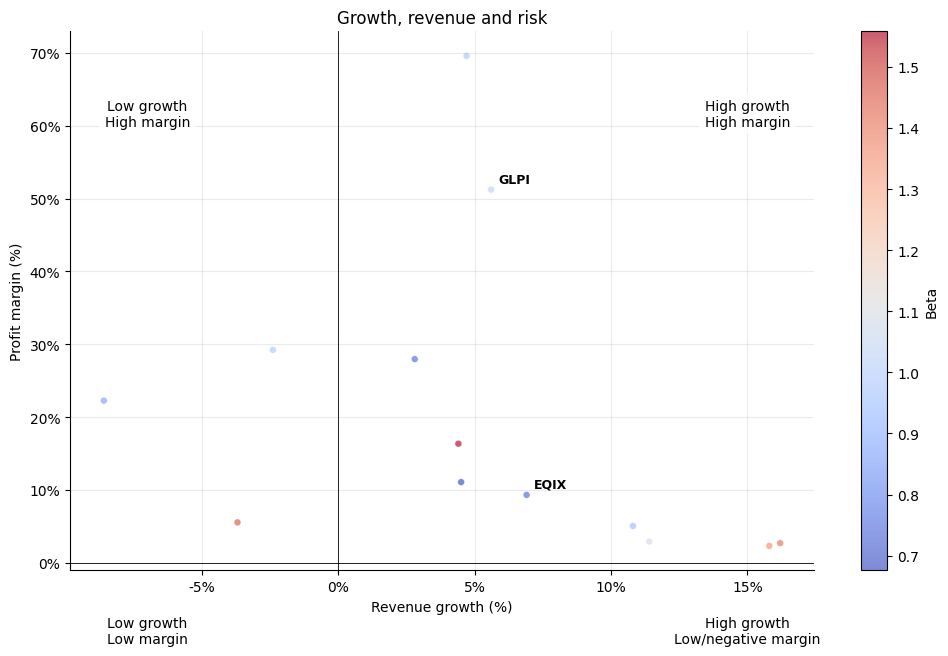

In [ ]:
# On the Beta Study there was just a qudrant represented by the second quadrant (high growth and hign beta), and no other quarant to do a comparison so I just 
# decided to change the study and do it like the professor.



# So at firts I select just the big companies with a market capitalization greater or equal to 10, and then a revenue rowth and profit margin capitalization 
# in the reange (-50, 80), and the beta. 
 
growth_df = df[
    (df["market_cap_bil"] >= 10) &
    (df["revenue_growth_pct"].between(-50, 100)) &
    (df["profit_margin_pct"].between(-50, 80)) &
    (df["beta"].between(0, 3))
].dropna(subset=["revenue_growth_pct", "profit_margin_pct", "beta", "market_cap_bil"]).copy()


# I set the general figure

fig, ax = plt.subplots(figsize=(12, 7))

sizes = (growth_df["market_cap_bil"] / 8).clip(lower=25, upper=600)

points = ax.scatter(
    growth_df["revenue_growth_pct"],    # the measure each axes represent
    growth_df["profit_margin_pct"],
    s=sizes,
    c=growth_df["beta"],
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)

# Then I set the references color for the axes

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)

# I add the labels for each qadrant according to the axes

ax.text(15, 60, "High growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(15, -11, "High growth\nLow/negative margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-7, 60, "Low growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-7, -11, "Low growth\nLow margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

# From the graph I select and annotate some companies with positive measuer but low beta. I do different try and I saw that be sure that some companies name
# compare, the labels have to be lower that 10 or 15. So I just set te value according to my sector in such a way that I can see some names.

candidates_for_labels = growth_df[
    (growth_df["revenue_growth_pct"] > 5) &
    (growth_df["profit_margin_pct"] > 8) & 
    (growth_df["beta"] < 1.5)
].nlargest(10, "market_cap_bil")



for _, row in candidates_for_labels.iterrows():
    ax.annotate(
        row["symbol"],
        (row["revenue_growth_pct"], row["profit_margin_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

# Then I set the general label of the graph

ax.set_title("Growth, revenue and risk")
ax.set_xlabel("Revenue growth (%)")
ax.set_ylabel("Profit margin (%)")

ax.xaxis.set_major_formatter(FuncFormatter(percentage_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(percentage_formatter))
ax.grid(alpha=0.25)
clean_spines(ax)

cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Beta")

plt.show()

## Step 7 - Zoom in the quadrant

In [26]:
# I choose the "High growth + High margin" quadrant because companies here show both strong revenue growth and high profitability, making them the
# most attractive candidates for investment in the Real Estate sector.


# So i choose the quadrant with revenue and growth grater than zero
quadrant_df = growth_df[
    (growth_df["revenue_growth_pct"] > 0) &
    (growth_df["profit_margin_pct"] > 0)
].copy()

# I select the top 10
if len(quadrant_df) > 10:
    quadrant_df = quadrant_df.nlargest(10, "market_cap_bil")

print("Companies in quadrant:", quadrant_df.shape[0])
print(quadrant_df[["symbol", "company_name", "beta", "profit_margin_pct", "market_cap_bil"]])

Companies in quadrant: 10
    symbol                     company_name   beta  profit_margin_pct  \
136   EQIX                    Equinix, Inc.  0.734           9.328000   
232    DLR       Digital Realty Trust, Inc.  0.676          11.086001   
300   CBRE                   CBRE Group Inc  1.420           2.706000   
328   VICI             VICI Properties Inc.  0.967          69.594002   
330   CSGP               CoStar Group, Inc.  0.931           5.069000   
401    IRM  Iron Mountain Incorporated (Del  1.078           2.929000   
429   SBAC   SBA Communications Corporation  0.739          27.972001   
621   GLPI  Gaming and Leisure Properties,   1.019          51.230997   
682    JLL  Jones Lang LaSalle Incorporated  1.360           2.333000   
700   LAMR        Lamar Advertising Company  1.558          16.358000   

     market_cap_bil  
136       82.899657  
232       51.900203  
300       39.043924  
328       33.825069  
330       33.327688  
401       25.975482  
429       23.851

In [27]:
import yfinance as yf

tickers = quadrant_df["symbol"].tolist() + ["^GSPC"]

# Download daily closing prices for the last 3 months
data = yf.download(tickers, period="3mo", interval="1d", auto_adjust=True)
closing_prices = data["Close"]


[*********************100%***********************]  11 of 11 completed


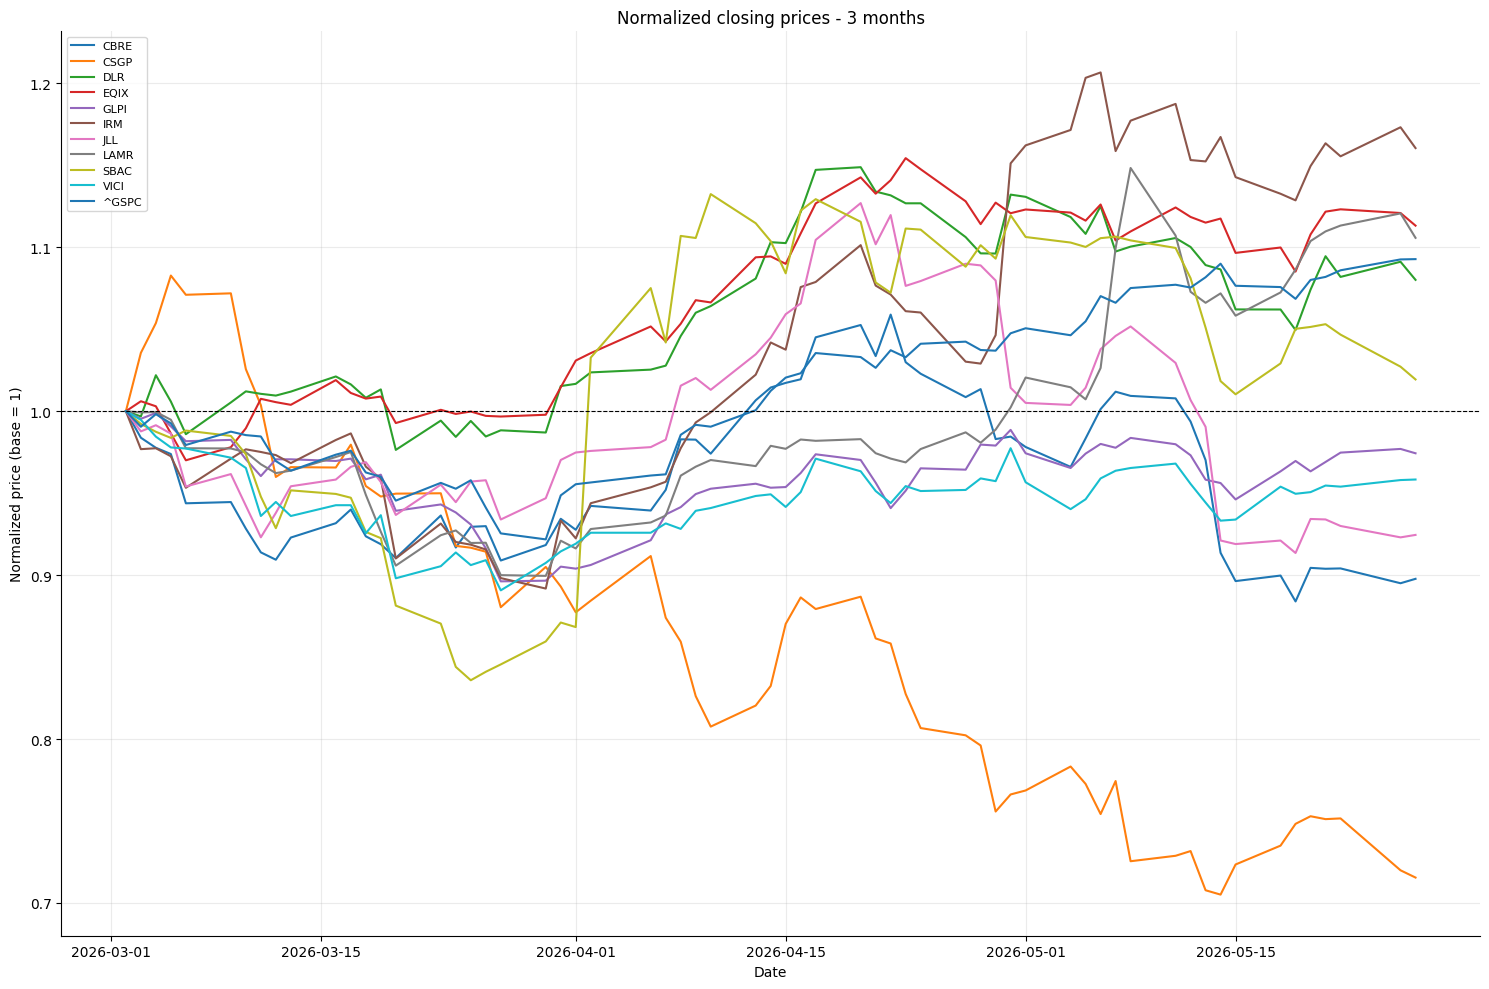

In [28]:
# Normalize all series to 1 on the first trading day to divide each value by the firsg row mean day = 1 for all tickers, so 
# line start all at the same point and percnetage moves are directly comparable

normalized = closing_prices / closing_prices.iloc[0]

# To set the general plot: 

fig, ax = plt.subplots(figsize=(15, 10))

for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Normalized closing prices - 3 months")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price (base = 1)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
clean_spines(ax)
plt.tight_layout()
plt.show()

The Real Estate Investment Trust (REIT) is a company that owns and manages property for income. It operates as a fund in which investors can buy shares in the company and receive a share of the rental income in the form of dividends, without directly owning any property.
For this reason in the graph “Mean metrics by indistries”, we saw industry like “Hotel & Motel”, “Office”,  “Health care faciliteis”.


Looking at the normalized price chart over the last 3 months, most companies in the "High Growth + High Margin" quadrant started above the normalized baseline of 1, reflecting strong market capitalization at the beginning of the period, with low companies under the normalized price 1.

The closure of the Strait of Hormuz on February 28th generate a visible market reaction. 
From the first March, a general decline is observable across most companies, with several reaching their lowest point between the 15th March and early April. The most affected company was SBAC n this quarter. 
The second company that was affected in a really impoart way is CSGP that, which has fallen further around the -0,83 between the first april and the 15th april.


From early April, a broad recovery began. The largest companies registered a significant rebound between April 1st and April 15th, with the highest values reaching approximately +1,17, and in general an upward movement is visible between April 15th and May 5th, with peak values around +1.20.


The only exception is CSGP, which failed to recover and instead continued to decline, falling to approximately -0.70 by mid-May. 

## STEP 8 - Compare with an Excluded Quadrant

In [ ]:
excl_quadrant = growth_df[
    (growth_df["revenue_growth_pct"] < 0) &
    (growth_df["profit_margin_pct"] > 0)
].copy()

# I select the top 10
if len(excl_quadrant) > 10:
    excl_quadrant = excl_quadrant.nlargest(10, "market_cap_bil")

print("Companies in quadrant:", excl_quadrant.shape[0])
print(excl_quadrant[["symbol", "company_name", "beta", "profit_margin_pct", "market_cap_bil"]])

Companies in quadrant: 3
    symbol                     company_name   beta  profit_margin_pct  \
112    AMT  American Tower Corporation (REI  0.861          22.267000   
460     WY             Weyerhaeuser Company  1.460           5.559000   
634    WPC            W. P. Carey Inc. REIT  0.974          29.233998   

     market_cap_bil  
112      101.078221  
460       21.847153  
634       13.481129  


In [ ]:

tickers = excl_quadrant["symbol"].tolist() + ["^GSPC"]

# Download daily closing prices for the last 3 months
data = yf.download(tickers, period="3mo", interval="1d", auto_adjust=True)
closing_prices = data["Close"]

[*********************100%***********************]  4 of 4 completed


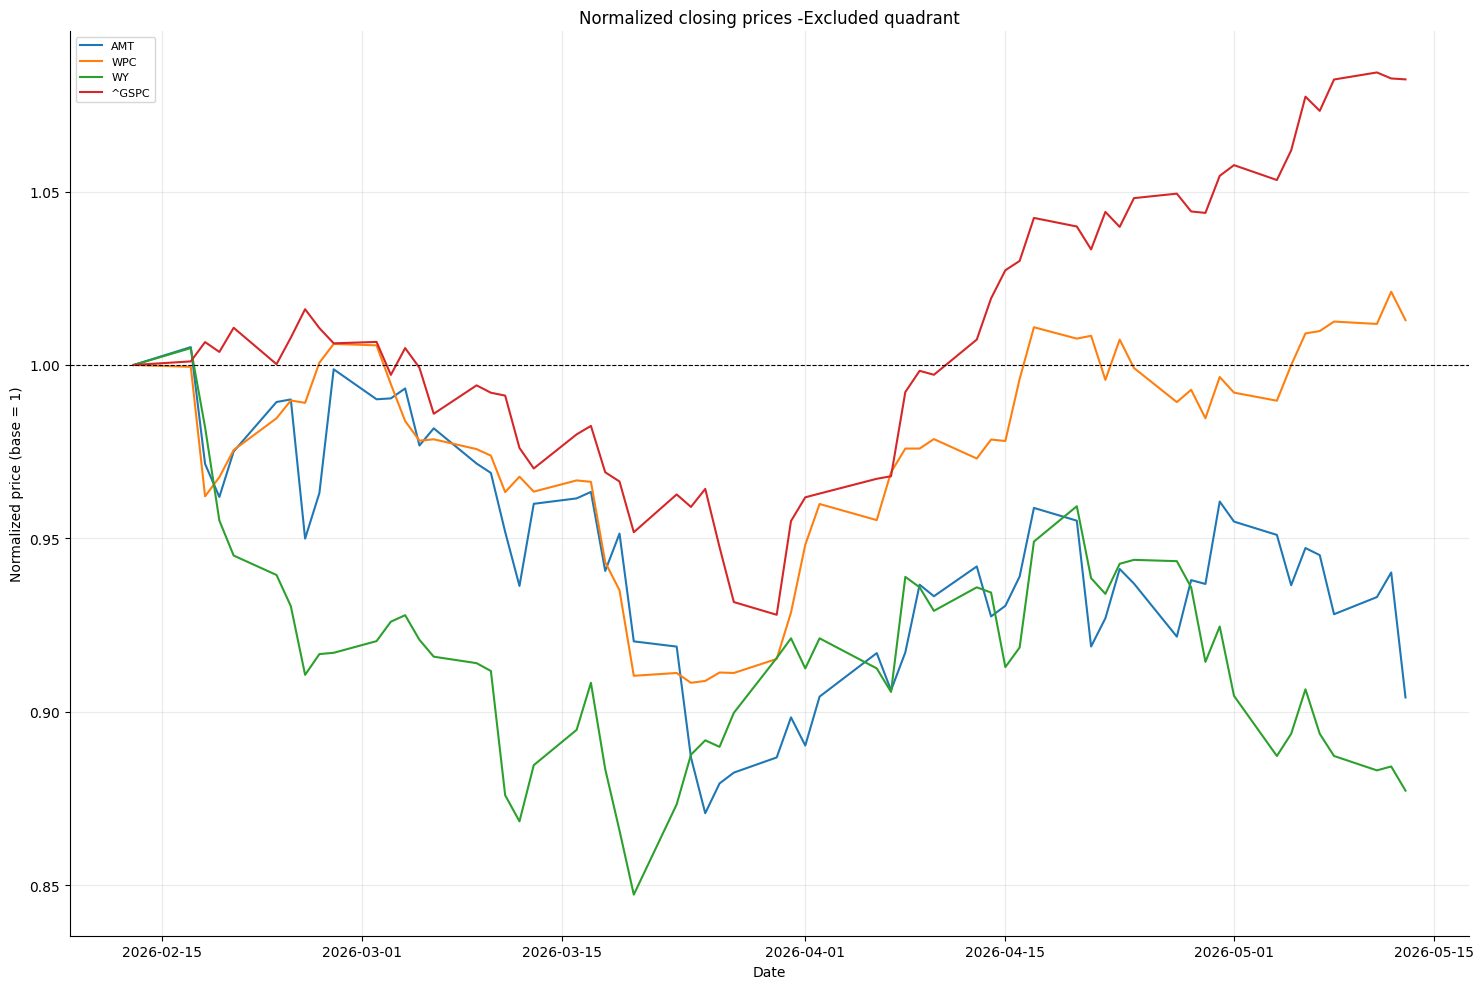

In [ ]:
# Normalize all series to 1 on the first trading day to divide each value by the firsg row mean day = 1 for all tickers, so 
# line start all at the same point and percnetage moves are directly comparable

normalized = closing_prices / closing_prices.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))

for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Normalized closing prices -Excluded quadrant")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price (base = 1)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
clean_spines(ax)
plt.tight_layout()
plt.show()

The quadrant I choose represents companies characterized by low growth and high margins. In this specific case, the group consists of no more than four companies.

Generally, the capitalization of these companies is around the normalized price starting from February 1st. However, between March 1st and March 15th, they experienced a decrease, with WY reaching its lowest point at approximately -0.85.

After March 15th, while WY began to recover, AMT hit its minimum at around -0.90. Following this period, only WPC managed to stabilize back at the normalized value of 1. In contrast, WY and AMT continued to decline, while only the ^GSPC index rose above the normalized price.

## Final Summary

In [ ]:

mark_bil = df["market_cap_bil"].mean()
rev_bil = df["revenue_bil"].mean()
margin_pct = df["profit_margin_pct"].mean()
b = df["beta"].mean()

print(mark_bil, rev_bil, margin_pct, b)


30.232162735157893 11.538000215578947 24.31405280765734 1.035631587630824



This study analyses the real estate sector, focusing on REIT (Real Estate Investment Trusts). A REIT is a company that owns, manages or finances income-generating properties such as offices, hospitals, warehouses and shopping centres. And it differ from other companies in terms of their tax obligations: by law, they must distribute at least 90% of their taxable income to shareholders in the form of dividends. In return, the company does not pay corporation tax at the corporate level (in this case they avoid the double taxation of the  shareholders)The sector has an average market capitalisation of around USD 30 billion, average revenue of around USD 11 billion, an average profit margin of around 24% and a beta consistently around 1, suggesting moderate market risk.

-----------------------------------------------------------------------------------------------

The four sectors selected for more detailed analysis reflect
specific conditions that I have decided to examine in more detail.
 
The first sector is "REIT Specialised", which appears in all the charts with a high average market capitalisation, high total revenue (third highest overall) and a beta close to 1. However, their profit margin is among the lowest. 

The second selection is "Real Esatet Services", characterised by the lowest beta value (around 0.8) and the highest average total revenues, among all sectors. However, it also has the lowest average profit margin in the entire classification. 


The third selection is "REIT - Diversified", which can be described as the "average" industry across all metrics — with a market capitalization of approximately 24 billion USD, a total revenue of around 3 billion USD, a profit margin ranking second among the selected industries, and a beta of approximately 0.95, close to the market benchmark.


The fourth selection is "REIT - Mortgage", which presents the lowest market capitalization (approximately 9 billion USD) and the lowest total revenue (approximately 2 billion USD), but the highest mean profit margin, exceeding 8%, combined with the highest beta of aournd 1,6. This is coherent with financial theory: higher profit margin is associated with higher risk.


-----------------------------------------------------------------------------------------------

The bubble chart was created by applying a number of filtering criteria. Firstly, only companies with a market capitalisation of $10 billion or more were included (and so REIT Mortgage companies were excluded). Given the relatively small size of the property sector, the filters were carefully calculated to ensure that at least two companies would be visible: revenue growth was filtered for values above 5, whilst profit margin was filtered for values above 8. If the filters had been stricter, no company names would have appeared on the chart. 
After applying these filters, two companies were identified: GLPI and EQIX. 

The chart reveals two populated quadrants: low growth with high margins and high growth with high margins. This confirms that most companies in this sector are profitable regardless of their growth rate, with market capitalisations exceeding $10 billion.


-----------------------------------------------------------------------------------------------

Looking at the chart of normalised prices over the last three months, the two groups of companies (those in the ‘low growth/high margin’ quadrant and those in the ‘high growth/high margin’ quadrant) have shown a broadly similar trend, with most starting above the normalised baseline of 1, reflecting strong initial market valuations.

The closure of the Strait of Hormuz on 28 February triggered a visible market reaction. A general decline began in early March, with most companies reaching their lowest point between mid-March and early April. The most affected company was SBAC, which fell to around 0,83 from its initial value.

A general recovery began in early April, with the larger companies rebounding to levels of around 1.17 by mid-April, reaching approximately 1.20 by early May. This suggests that investors regained their balance relatively quickly, possibly because real estate companies have limited direct exposure to oil price shocks: their revenues derive mainly from rents and property management rather than from energy markets.
The only significant exception was CSGP, which failed to recover and continued to fall to around 0.70 in mid-May, a drop of around 30%. This was likely due to difficulties within the company rather than market-related issues.


 Overall, the performance of both groups was generally in line with expectations: REIT, as it's characterised from a defensive assets by stable cash flows, had limited influence on price movements during the period under review, while macroeconomic and geopolitical factors prevailed.